`py-g5ht-pipeline`

__NOTE__

You will need ~200GB of storage space locally for a single recording. After registration, you can delete ~150GB
- .nd2: 50GB  (~55GB if separate channel alignment recording taken)
- .h5: 9GB
- .tifs created from shear_correction, channel_alignment, bleach_correction: 47GB each     (shear_correction, channel_alignment can be deleted after running the full pipeline)
- .tifs created from warping and registering: 18GB each      (warped can be deleted after running the full pipeline)

## IMPORTS

In [ ]:
import sys
import os
import importlib
from tqdm import tqdm
from pathlib import Path
from datetime import datetime
import shutil
import utils

## SPECIFY DATA TO PROCESS

In [2]:
data_dir = r'/store1/shared/g5ht/data' # this is a linux machine

# dataset (see datasets.txt)
dataset = 'date-20260112_strain-ISg5HT_condition-fedpatch_worm001.nd2'

NOISE_PTH = '/home/munib/code/g5ht-pipeline/noise/noise_111125.tif'

In [3]:
# directories and paths

INPUT_ND2 = dataset
date_str = INPUT_ND2.split('_')[0].split('-')[1]
local_dir = os.path.join(data_dir, date_str)
os.makedirs(local_dir, exist_ok=True)
INPUT_ND2_PTH = os.path.join(local_dir, INPUT_ND2)


OUT_DIR = utils.get_output_dir(INPUT_ND2_PTH)

STACK_LENGTH = 41 if 'immo' not in INPUT_ND2 else 122

# for recordings prior to roughly December 2025, we want to keep all but the last two z-slices, during which the piezo position is unstable
# after December 2025, we want to keep all but the first two z-slices, during which the piezo position is unstable at the beginning of the recording
date_obj = datetime.strptime(date_str, '%Y%m%d')
if date_obj < datetime(2025, 12, 1):
    z2keep =  (0,STACK_LENGTH-2) # tuple representing range of z-slices to keep, should keep all but the last two slices
else:
    z2keep =  (2,STACK_LENGTH) # tuple representing range of z-slices to keep, should keep all but the first two slices

# get noise stack and metadata from nd2
noise_stack = utils.get_noise_stack(NOISE_PTH, STACK_LENGTH)
num_frames, height, width, num_channels = utils.get_range_from_nd2(INPUT_ND2_PTH, stack_length=STACK_LENGTH) 
beads_alignment_file = utils.get_beads_alignment_file(INPUT_ND2_PTH)

## 1. SHEAR CORRECTION 

` conda activate g5ht-pipeline`

~ 1 hour for 1200 image stacks with 2 color channels, 41 z, 512 h, 512 w

- shear corrects each volume
  - depending on each exposure time, it can take roughly half a second between the first and last frames of a volume, so any movements need to be corrected for
- creates one `.tif` for each volume and stores it in the `shear_corrected` directory

In [4]:
import shear_correct
_ = importlib.reload(sys.modules['shear_correct'])

start_index = "0"
end_index = str(num_frames-1)
# start_index = "515"
# end_index = str(num_frames-1)

ncpu = str(utils.get_optimal_cpu_count())

skip_shear_correction = False # if True, will just denoise and save as tif

# sys.argv = ["", nd2 file, start_frame, end_frame, noise_pth, stack_length, n_workers, num_frames, height, width, num_channels]
sys.argv = ["", INPUT_ND2_PTH, start_index, end_index, NOISE_PTH, STACK_LENGTH, ncpu, num_frames, height, width, num_channels, z2keep, skip_shear_correction]

# Call the main function
shear_correct.main()

System Load: 2.8% | Available: 62.21 | Allocating: 16
Processing 521 stacks (0-520) using 16 workers...


100%|██████████| 521/521 [20:58<00:00,  2.42s/it]


Parallel preprocessing complete.


## 2. CHANNEL ALIGNMENT

` conda activate g5ht-pipeline`

Takes around 30 minutes for 1200 image stacks with 2 color channels, 39 z, 512 h, 512 w

### 2a. GET MEDIAN CHANNEL ALIGNMENT PARAMETERS FROM ALL FRAMES

- If channel alignment file found, uses that, if not uses worm recording
- creates a `.txt` file for each volume that contains elastix channel registration parameters
- creates `chan_align_params.csv` and  `chan_align.txt`

In [9]:
import get_channel_alignment
import median_channel_alignment
_ = importlib.reload(sys.modules['get_channel_alignment'])
_ = importlib.reload(sys.modules['median_channel_alignment'])

## set beads_alignment_file to None to use worm recording for channel alignment, even if beads file exists
# beads_alignment_file = None

start_index = "0"
end_index = str(num_frames-1)

ncpu = str(utils.get_optimal_cpu_count())


every_other = True # if True, will only use every other frame for channel alignment, which should be sufficient and will speed up the process by 2x

if beads_alignment_file is not None:
    align_with_beads = True
    every_other = False # if using beads for alignment, we want to use all frames because there's only 50
    num_frames_beads, _, _, _ = utils.get_range_from_nd2(beads_alignment_file, stack_length=STACK_LENGTH) 
    sys.argv = ["", beads_alignment_file, start_index, end_index, NOISE_PTH, STACK_LENGTH, ncpu, num_frames_beads, height, width, num_channels, every_other, align_with_beads]
else:
    align_with_beads = False
    sys.argv = ["", INPUT_ND2_PTH, start_index, end_index, NOISE_PTH, STACK_LENGTH, ncpu, num_frames, height, width, num_channels, every_other, align_with_beads]

# # Call the main function
get_channel_alignment.main()
median_channel_alignment.main()


System Load: 5.9% | Available: 60.22 | Allocating: 16
Processing 261 stacks (0-520) using 16 workers...


  0%|          | 0/261 [00:00<?, ?it/s]

  Writing image ...
  Writing image ...


  0%|          | 1/261 [00:26<1:54:22, 26.40s/it]

  Writing image ...


...

  Writing image ...


 99%|█████████▉| 259/261 [04:11<00:01,  1.68it/s]

  Writing image ...
  Writing image ...


100%|██████████| 261/261 [04:12<00:00,  1.03it/s]


Parallel preprocessing complete.


### 2b. APPLY MEDIAN CHANNEL ALIGNMENT PARAMETERS

- ouputs aligned volumes in `channel_aligned` directory

In [11]:
import apply_channel_alignment
_ = importlib.reload(sys.modules['apply_channel_alignment'])

start_index = "0"
end_index = str(num_frames-1)

ncpu = str(utils.get_optimal_cpu_count())

if beads_alignment_file is not None:
    align_with_beads = True
    num_frames_beads, _, _, _ = utils.get_range_from_nd2(beads_alignment_file, stack_length=STACK_LENGTH) 
    sys.argv = ["", INPUT_ND2_PTH, start_index, end_index, NOISE_PTH, STACK_LENGTH, ncpu, num_frames, height, width, num_channels, align_with_beads, beads_alignment_file]
else:
    align_with_beads = False
    sys.argv = ["", INPUT_ND2_PTH, start_index, end_index, NOISE_PTH, STACK_LENGTH, ncpu, num_frames, height, width, num_channels, align_with_beads]


# Call the main function
apply_channel_alignment.main()

System Load: 5.9% | Available: 60.22 | Allocating: 16
Processing 521 stacks (0-520) using 16 workers...


100%|██████████| 521/521 [01:47<00:00,  4.86it/s]


Parallel preprocessing complete.


### 2c. PLOT CHANNEL ALIGNMENT PARAMETER DISTRIBUTIONS

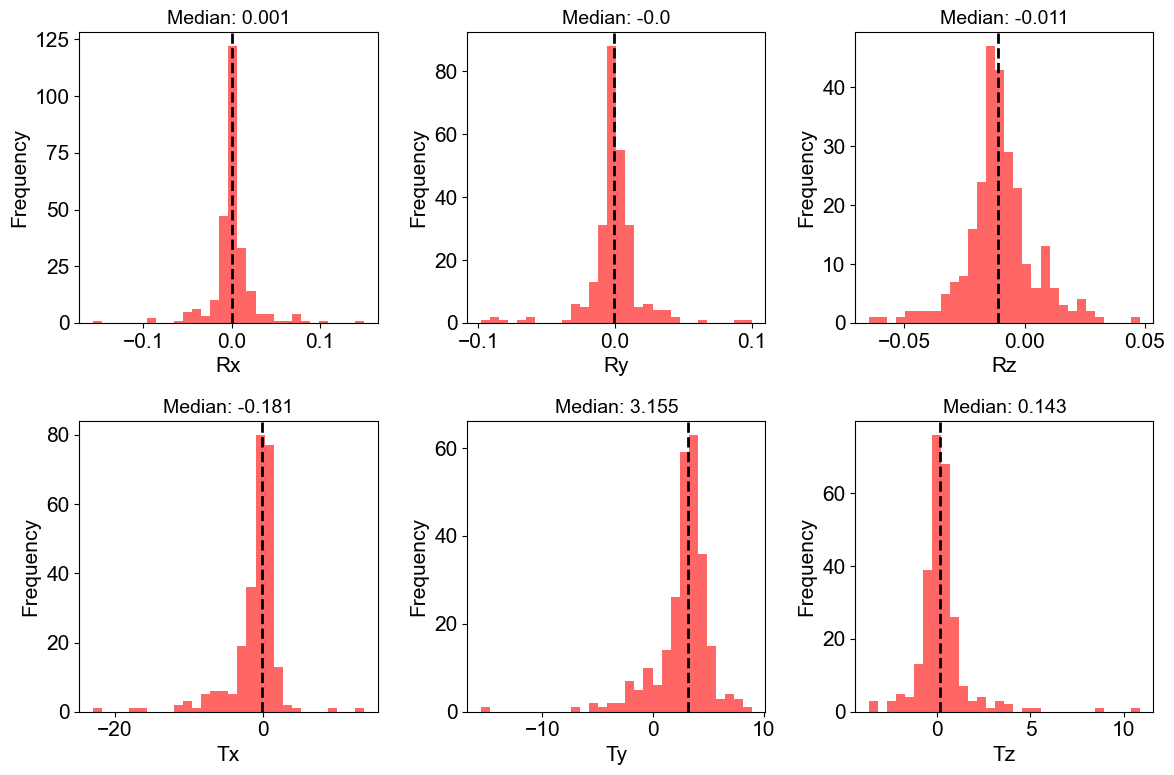

In [13]:
import apply_channel_alignment
_ = importlib.reload(sys.modules['apply_channel_alignment'])

apply_channel_alignment.plot_channel_alignment_params(INPUT_ND2_PTH, beads_alignment_file)

## 3. BLEACH CORRECTION

Takes about 5 minutes

In [15]:
import importlib
import os
import sys

import bleach_correct
_ = importlib.reload(sys.modules['bleach_correct'])


PTH = os.path.splitext(INPUT_ND2_PTH)[0]
REG_DIR = 'channel_aligned' # 'channel_aligned' or 'tif' 
channels = 1 # 0-gfp, 1-rfp
method = 'block' # 'block' or 'exponential'
mode = 'total' # 'total' or 'median'
output_dir = os.path.join(PTH, 'bleach_corrected')

bleach_correct.correct_bleaching(os.path.join(PTH,REG_DIR), output_dir=output_dir, channels=channels, method=method, fbc=0.04, intensity_mode=mode)

Found 521 volumes in /store1/shared/g5ht/data/20260112/date-20260112_strain-ISg5HT_condition-fedpatch_worm001/channel_aligned
Channels to correct: ['RFP']
Method: block
Intensity mode: total

Processing RFP channel (index 1)
  Calculating total RFP signal...
Calculating RFP total signal: volume 521/521
  Divided into 25 blocks
  Computing block mean signals...
    Block 1/25: volumes 0-62, mean signal = 2.76e+08
    Block 2/25: volumes 63-90, mean signal = 2.75e+08
    Block 3/25: volumes 91-109, mean signal = 2.73e+08
    Block 4/25: volumes 110-121, mean signal = 2.72e+08
    Block 5/25: volumes 122-133, mean signal = 2.71e+08
    Block 6/25: volumes 134-146, mean signal = 2.69e+08
    Block 7/25: volumes 147-159, mean signal = 2.68e+08
    Block 8/25: volumes 160-170, mean signal = 2.66e+08
    Block 9/25: volumes 171-176, mean signal = 2.65e+08
    Block 10/25: volumes 177-197, mean signal = 2.63e+08
    Block 11/25: volumes 198-208, mean signal = 2.62e+08
    Block 12/25: volumes 

## 4. MIP

` conda activate g5ht-pipeline`

- outputs `means.png`, `focus.png`, `mip.tif`, and `mip.mp4`, `focus_check.csv`

##### TODO: 
- mip for xy, xz, zy
- mip for several slices

In [4]:
import mip
_ = importlib.reload(sys.modules['mip'])

# command-line arguments
framerate = 8
tif_dir = 'bleach_corrected' # one of 'shear_corrected' 'channel_aligned' 'bleach_corrected'
# tif_dir = 'shear_corrected'
rmax = 850
gmax = 150
mp4_quality = 10
do_focus = True
sys.argv = ["", INPUT_ND2_PTH, tif_dir, STACK_LENGTH, num_frames, framerate, rmax, gmax, mp4_quality, do_focus]

# Call the main function
mip.main()

Checking focus... 

100%|██████████| 521/521 [00:09<00:00, 55.41it/s]
<tifffile.TiffWriter 'mip_bleach_corrected.tif'> writing nonconformant BigTIFF ImageJ


0000.tif written to mip_bleach_corrected.tif
0001.tif written to mip_bleach_corrected.tif
0002.tif written to mip_bleach_corrected.tif
0003.tif written to mip_bleach_corrected.tif
0004.tif written to mip_bleach_corrected.tif
0005.tif written to mip_bleach_corrected.tif
0006.tif written to mip_bleach_corrected.tif
0007.tif written to mip_bleach_corrected.tif
0008.tif written to mip_bleach_corrected.tif
0009.tif written to mip_bleach_corrected.tif
0010.tif written to mip_bleach_corrected.tif
0011.tif written to mip_bleach_corrected.tif
0012.tif written to mip_bleach_corrected.tif
0013.tif written to mip_bleach_corrected.tif
0014.tif written to mip_bleach_corrected.tif
0015.tif written to mip_bleach_corrected.tif
0016.tif written to mip_bleach_corrected.tif
0017.tif written to mip_bleach_corrected.tif
0018.tif written to mip_bleach_corrected.tif
0019.tif written to mip_bleach_corrected.tif
0020.tif written to mip_bleach_corrected.tif
0021.tif written to mip_bleach_corrected.tif
0022.tif w

[swscaler @ 0x7ca6e4015040] deprecated pixel format used, make sure you did set range correctly


## 5 DRIFT ESTIMATION

` conda activate g5ht-pipeline`

- outputs  `z_selection.csv`, `z_selection_diagnostics.png`, `sharpness.csv`

Few minutes to run

TODO:
- use z selection going forward
- also use sharpness/focus (and other things) to determine good/bad frames

In [5]:
import drift_estimation
_ = importlib.reload(sys.modules['drift_estimation'])

# command-line arguments
tif_dir = 'bleach_corrected' # one of 'shear_corrected' 'channel_aligned' 'bleach_corrected'

sys.argv = ["", INPUT_ND2_PTH, tif_dir, STACK_LENGTH, num_frames]

# Call the main function
drift_estimation.main()

Computing sharpness-based focus metrics...


Computing sharpness: 100%|██████████| 521/521 [01:12<00:00,  7.22it/s]



Z-slice selection complete:
  Total frames: 521
  Z-slices per frame: 24
  Frames needing padding: 459 (88.1%)
  Total drift: 8.14 z-slices
  Max drift from start: 8.56 z-slices
